In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

models = {
    # Baseline: satu pohon keputusan
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    # Bagging: 100 pohon dilatih paralel dengan data acak berbeda
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    # Boosting: pohon dilatih berurutan, memperbaiki error model sebelumnya
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, "accuracy:", round(accuracy_score(y_test, pred), 3))

DecisionTree accuracy: 0.947
RandomForest accuracy: 0.965
GradientBoosting accuracy: 0.956


##Ensemble Learning (Decision Tree, Random Forest, Gradient Boosting)

#Tujuan
Tujuan dari praktikum ini adalah untuk membandingkan performa beberapa algoritma klasifikasi yaitu Decision Tree, Random Forest, dan Gradient Boosting pada dataset Iris. Selain itu juga untuk mengetahui fitur yang paling berpengaruh dalam klasifikasi serta melihat pengaruh jumlah pohon (n_estimators) pada Random Forest.

#Langkah Kerja
1. Mengimport library yang dibutuhkan seperti pandas, NumPy, seaborn, matplotlib dan sklearn.
2. Memuat dataset Iris dari sklearn.
3. Membagi data menjadi data training dan data testing menggunakan train_test_split.
4. Melatih tiga model klasifikasi yaitu Decision Tree, Random Forest, dan Gradient Boosting.
5.  Menghitung nilai akurasi dari masing-masing model.
6. Menampilkan Feature Importance dari model Random Forest.
7. Melakukan eksperimen dengan beberapa nilai n_estimators pada Random Forest.
8. Menampilkan grafik pengaruh n_estimators terhadap akurasi model.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

Pada bagian ini dilakukan proses mengimpor beberapa library yang akan digunakan dalam program. Library pandas digunakan untuk membantu pengolahan data dalam bentuk tabel atau DataFrame. Library seaborn dan matplotlib digunakan untuk membuat visualisasi grafik sehingga hasil analisis dapat ditampilkan dengan lebih jelas. Library numpy digunakan untuk membantu perhitungan numerik. Selain itu digunakan juga library scikit-learn yang menyediakan dataset serta berbagai algoritma machine learning seperti Decision Tree, Random Forest, dan Gradient Boosting yang digunakan dalam proses klasifikasi.

In [3]:
# --- PERSIAPAN DATA ---
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

Pada bagian ini dataset Iris dimuat menggunakan fungsi load_iris(). Dataset tersebut kemudian dibagi menjadi data training dan data testing menggunakan fungsi train_test_split(). Sebanyak 80% data digunakan untuk melatih model dan 20% data digunakan untuk pengujian model.

In [4]:
#BANDINGKAN DT VS RANDOM FOREST VS GRADIENT BOOSTING
print("--- :PERBANDINGAN MODEL ENSEMBLE ---")
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.3f}")

--- :PERBANDINGAN MODEL ENSEMBLE ---
Decision Tree Accuracy: 1.000
Random Forest Accuracy: 1.000
Gradient Boosting Accuracy: 1.000


Pada bagian ini saya membandingkan tiga model klasifikasi yaitu Decision Tree, Random Forest, dan Gradient Boosting. Setiap model dilatih menggunakan data training kemudian digunakan untuk memprediksi data testing. Setelah itu nilai akurasi dihitung untuk melihat seberapa baik setiap model dalam melakukan klasifikasi data.

In [5]:
#TAMPILKAN FITUR TERPENTING (FEATURE IMPORTANCE)===============================================================

rf_model = models["Random Forest"]
importances = rf_model.feature_importances_
feature_names = iris.feature_names


df_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False)

print("\n--- TUGAS 2: FEATURE IMPORTANCE (RANDOM FOREST) ---")
print(df_importance)


--- TUGAS 2: FEATURE IMPORTANCE (RANDOM FOREST) ---
             Feature  Importance
2  petal length (cm)    0.439994
3   petal width (cm)    0.421522
0  sepal length (cm)    0.108098
1   sepal width (cm)    0.030387


Pada bagian ini saya menampilkan feature importance dari model Random Forest. Feature importance digunakan untuk mengetahui fitur mana yang paling berpengaruh dalam proses klasifikasi. Hasilnya ditampilkan dalam bentuk tabel yang menunjukkan tingkat kepentingan setiap fitur pada dataset Iris.

Text(0.5, 1.0, 'Feature Importance')

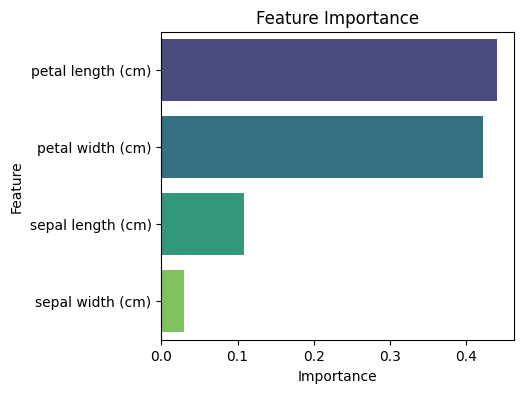

In [6]:
# Visualisasi Feature Importance
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance')


Pada bagian ini hasil feature importance divisualisasikan menggunakan grafik batang. Grafik ini membantu melihat fitur mana yang memiliki pengaruh paling besar terhadap hasil klasifikasi pada dataset Iris.

In [8]:
#PENGARUH N_ESTIMATORS PADA RANDOM FOREST

print("\n--- TUGAS 3: EKSPERIMEN N_ESTIMATORS ---")
n_list = [10, 50, 100, 200]
n_results = []

for n in n_list:
    model_n = RandomForestClassifier(n_estimators=n, random_state=42)
    model_n.fit(X_train, y_train)
    acc_n = accuracy_score(y_test, model_n.predict(X_test))
    n_results.append(acc_n)
    print(f"n_estimators={n} | Accuracy: {acc_n:.3f}")


--- TUGAS 3: EKSPERIMEN N_ESTIMATORS ---
n_estimators=10 | Accuracy: 1.000
n_estimators=50 | Accuracy: 1.000
n_estimators=100 | Accuracy: 1.000
n_estimators=200 | Accuracy: 1.000


Pada bagian ini saya melakukan percobaan dengan beberapa nilai n_estimators pada Random Forest. Parameter ini menunjukkan jumlah pohon keputusan yang digunakan dalam model. Percobaan ini dilakukan untuk melihat bagaimana jumlah pohon mempengaruhi akurasi model.

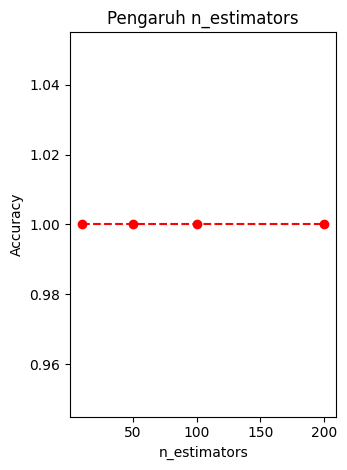

In [9]:
# Visualisasi Pengaruh n_estimators
plt.subplot(1, 2, 2)
plt.plot(n_list, n_results, marker='o', linestyle='--', color='red')
plt.title('Pengaruh n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

Pada bagian ini hasil percobaan divisualisasikan menggunakan grafik garis. Grafik tersebut menunjukkan hubungan antara jumlah pohon pada Random Forest dengan nilai akurasi yang dihasilkan oleh model.

In [11]:
# --- KESIMPULAN ---
print("\n=== KESIMPULAN ===")
print("1. Teknik Ensemble (RF & GB) cenderung memberikan hasil yang lebih stabil dibanding satu pohon (DT).")
print("2. Berdasarkan Feature Importance, 'petal width' dan 'petal length' adalah faktor penentu utama spesies bunga Iris.")
print("3. Menambah n_estimators meningkatkan akurasi hingga titik tertentu sebelum akhirnya stabil (plateau).")


=== KESIMPULAN ===
1. Teknik Ensemble (RF & GB) cenderung memberikan hasil yang lebih stabil dibanding satu pohon (DT).
2. Berdasarkan Feature Importance, 'petal width' dan 'petal length' adalah faktor penentu utama spesies bunga Iris.
3. Menambah n_estimators meningkatkan akurasi hingga titik tertentu sebelum akhirnya stabil (plateau).


Pada bagian ini program menampilkan kesimpulan dari hasil percobaan yang telah dilakukan. Kesimpulan tersebut dicetak menggunakan perintah `print()` sehingga muncul sebagai output pada program. Isi kesimpulan menjelaskan bahwa metode ensemble seperti Random Forest dan Gradient Boosting memberikan hasil yang lebih stabil dibandingkan Decision Tree. Selain itu, fitur petal width dan petal length memiliki pengaruh paling besar dalam menentukan jenis bunga Iris. Percobaan jumlah n_estimators juga menunjukkan bahwa penambahan jumlah pohon dapat meningkatkan akurasi hingga mencapai titik tertentu sebelum akhirnya stabil.

#Kesimpulan
Berdasarkan praktikum yang telah dilakukan dapat disimpulkan bahwa metode ensemble seperti Random Forest dan Gradient Boosting dapat memberikan hasil klasifikasi yang baik pada dataset Iris. Selain itu beberapa fitur seperti petal length dan petal width memiliki pengaruh besar dalam menentukan jenis bunga. Percobaan jumlah n_estimators juga menunjukkan bahwa peningkatan jumlah pohon dapat meningkatkan performa model hingga mencapai nilai yang stabil.